<a href="https://colab.research.google.com/github/slymnvbrahim/Heart_Disease_Mortality_Among_US_Adults/blob/main/Heart_Disease_Mortality_Among_US_Adults.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "/content/Heart.csv"
heart_df = pd.read_csv(url)
heart_df.head(10)

,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,...,Data_Value_Footnote,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,TopicID,LocationID,Y_lat,X_lon,Georeference
0,2020,AS,American Samoa County,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Insufficient Data,Sex,Male,Race/Ethnicity,Black,T2,60000,-14.301754,-170.719474,POINT (-170.7194738 -14.30175426)
1,2020,ND,North Dakota,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,Insufficient Data,Sex,Female,Race/Ethnicity,Asian,T2,38,47.447100,-100.470000,POINT (-100.47 47.4471)
2,2020,PA,Pennsylvania,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,616,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Male,Race/Ethnicity,Black,T2,42,40.874900,-77.802200,POINT (-77.8022 40.8749)
3,2020,CA,California,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,229.5,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Overall,Race/Ethnicity,Hispanic,T2,6,37.241400,-119.601000,POINT (-119.601 37.2414)
4,2020,IA,Iowa,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,190.6,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Overall,Race/Ethnicity,Asian,T2,19,42.076000,-93.502200,POINT (-93.5022 42.076)
5,2020,HI,Hawaii,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,291.8,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Female,Race/Ethnicity,More than one race,T2,15,20.240800,-156.326000,POINT (-156.326 20.2408)
6,2020,RI,Rhode Island,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,248.1,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Female,Race/Ethnicity,White,T2,44,41.682000,-71.561700,POINT (-71.5617 41.682)
7,2020,GA,Georgia,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,111.4,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Female,Race/Ethnicity,Hispanic,T2,13,32.654900,-83.454700,POINT (-83.4547 32.6549)
8,2020,HI,Hawaii,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,327.9,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,NaN,Sex,Male,Race/Ethnicity,Overall,T2,15,20.240800,-156.326000,POINT (-156.326 20.2408)
9,2020,GU,Guam,State,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, 3-year Average Rate",...,Insufficient Data,Sex,Overall,Race/Ethnicity,Black,T2,66,13.443100,144.777000,POINT (144.777 13.4431)


In [ ]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78792 entries, 0 to 78791
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        78792 non-null  int64  
 1   LocationAbbr                78792 non-null  object 
 2   LocationDesc                78792 non-null  object 
 3   GeographicLevel             78792 non-null  object 
 4   DataSource                  78792 non-null  object 
 5   Class                       78792 non-null  object 
 6   Topic                       78792 non-null  object 
 7   Data_Value                  34430 non-null  object 
 8   Data_Value_Unit             78792 non-null  object 
 9   Data_Value_Type             78792 non-null  object 
 10  Data_Value_Footnote_Symbol  44362 non-null  object 
 11  Data_Value_Footnote         44362 non-null  object 
 12  StratificationCategory1     78792 non-null  object 
 13  Stratification1             787

In [ ]:
heart_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,78792.0,NaN,NaN,NaN,2020.0,0.0,2020.0,2020.0,2020.0,2020.0,2020.0
LocationAbbr,78792,57,TX,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LocationDesc,78792,2022,Washington County,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GeographicLevel,78792,3,County,77424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DataSource,78792,1,NVSS,78792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,78792,1,Cardiovascular Diseases,78792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topic,78792,1,Heart Disease Mortality,78792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_Value,34430,6837,293.7,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_Value_Unit,78792,1,"per 100,000 population",78792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data_Value_Type,78792,2,"Age-adjusted, Spatially Smoothed, 3-year Avera...",77424,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = heart_df.isnull().mean()*100
missing.sort_values(ascending=False).head(10)

,0
Data_Value,56.30267
Data_Value_Footnote_Symbol,43.69733
Data_Value_Footnote,43.69733
X_lon,0.03046
Georeference,0.03046
Y_lat,0.03046
DataSource,0.00000
LocationDesc,0.00000
LocationAbbr,0.00000
Year,0.00000


In [ ]:
heart_df["Data_Value"] = pd.to_numeric(
    heart_df["Data_Value"],
    errors="coerce"
)

In [ ]:
heart_df["Data_Value"].describe()

,Data_Value
count,34339.000000
mean,349.248114
std,152.452186
min,0.000000
25%,240.400000
50%,334.900000
75%,440.950000
max,996.500000


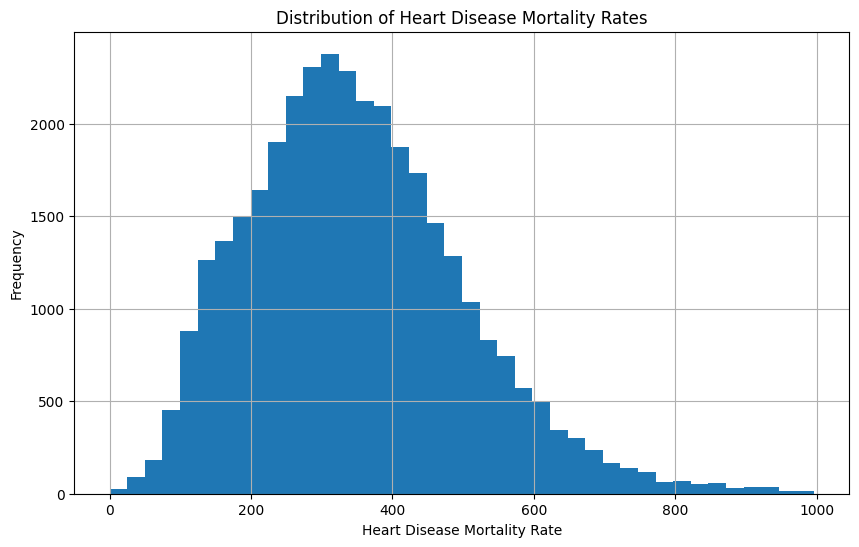

In [ ]:
heart_df["Data_Value"].hist(
    bins=40,
    figsize=(10, 6)
)

plt.xlabel("Heart Disease Mortality Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Disease Mortality Rates")
plt.show()

In [ ]:
sex_mortality = (
    heart_df
    .groupby("Stratification1")["Data_Value"]
    .mean()
    .sort_values()
)

sex_mortality

,Data_Value
Stratification1,
Female,273.044887
Overall,336.409896
Male,436.026719


In [ ]:
race_mortality = (
    heart_df
    .groupby("Stratification2")["Data_Value"]
    .mean()
    .sort_values()
)

race_mortality

,Data_Value
Stratification2,
Asian,170.992149
More than one race,195.870888
Hispanic,210.732521
Overall,368.346319
White,377.411740
American Indian or Alaska Native,379.039470
Native Hawaiian or Other Pacific Islander,443.732314
Black,466.577037


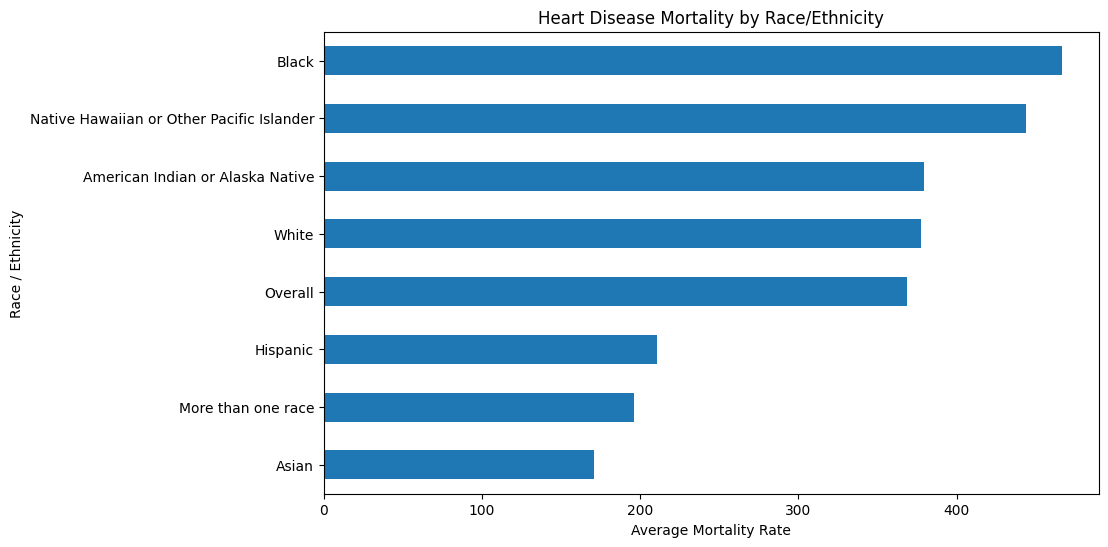

In [ ]:
race_mortality.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Average Mortality Rate")
plt.ylabel("Race / Ethnicity")
plt.title("Heart Disease Mortality by Race/Ethnicity")
plt.show()

In [ ]:
sex_race = (
    heart_df
    .groupby(["Stratification2", "Stratification1"])["Data_Value"]
    .mean()
    .unstack()
)

sex_race

Stratification1,Female,Male,Overall
Stratification2,,,
American Indian or Alaska Native,295.174242,481.236552,355.305092
Asian,132.123112,212.013630,168.159802
Black,367.104124,570.762920,455.751647
Hispanic,168.630389,256.523015,201.694652
More than one race,160.706757,257.441896,176.950389
Native Hawaiian or Other Pacific Islander,342.278947,559.876812,422.070874
Overall,281.659994,459.518118,363.838492
White,288.130082,471.052658,373.029909


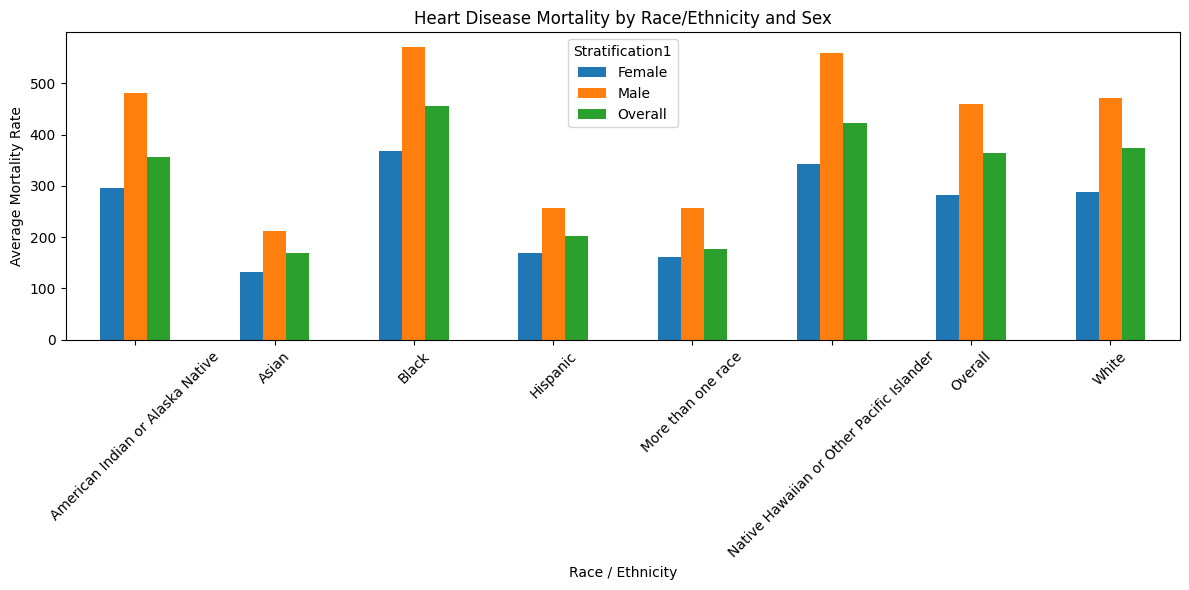

In [ ]:
sex_race.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Race / Ethnicity")
plt.ylabel("Average Mortality Rate")
plt.title("Heart Disease Mortality by Race/Ethnicity and Sex")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
state_df = heart_df[
    heart_df["GeographicLevel"] == "State"
].copy()

In [ ]:
state_overall = state_df[
    (state_df["Stratification1"] == "Overall") &
    (state_df["Stratification2"] == "Overall")
]

In [ ]:
state_rates = (
    state_overall
    .groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
)

state_rates.head(10)

,Data_Value
LocationDesc,
Guam,571.2
Oklahoma,477.7
Mississippi,467.8
Alabama,451.9
Arkansas,438.2
Louisiana,427.8
Tennessee,411.2
West Virginia,398.4
Kentucky,398.1


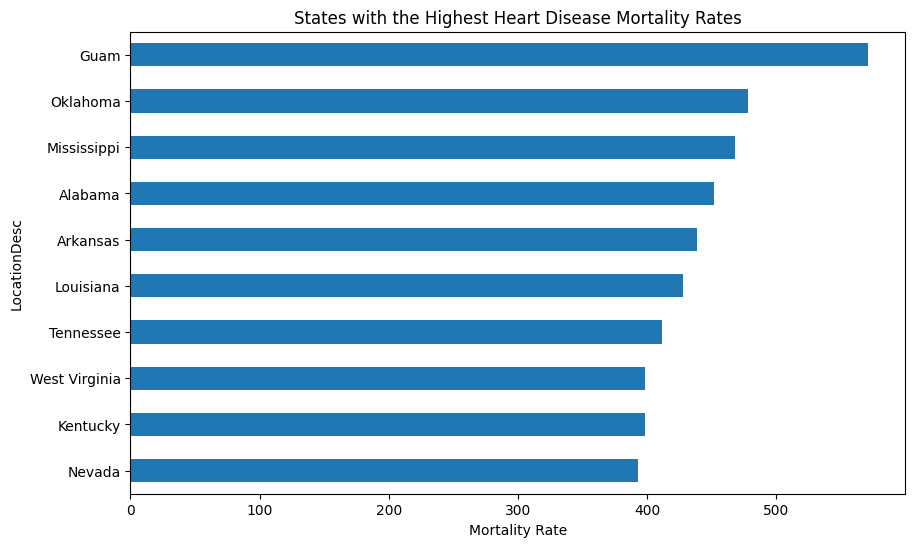

In [ ]:
state_rates.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Mortality Rate")
plt.title("States with the Highest Heart Disease Mortality Rates")
plt.show()

In [ ]:
county_df = heart_df[
    heart_df["GeographicLevel"] == "County"
].copy()

In [ ]:
county_overall = county_df[
    (county_df["Stratification1"] == "Overall") &
    (county_df["Stratification2"] == "Overall")
].copy()

In [ ]:
county_overall.nlargest(
    20,
    "Data_Value"
)[
    ["LocationDesc", "Data_Value"]
]

,LocationDesc,Data_Value
24297,Franklin Parish,859.0
28108,Perry County,835.6
6299,Walker County,834.0
32001,Caldwell Parish,832.4
49295,Pemiscot County,770.6
28533,Wolfe County,761.6
7346,Clinch County,757.0
29081,Tensas Parish,750.4
29093,Breathitt County,738.8
67055,Lake County,727.0


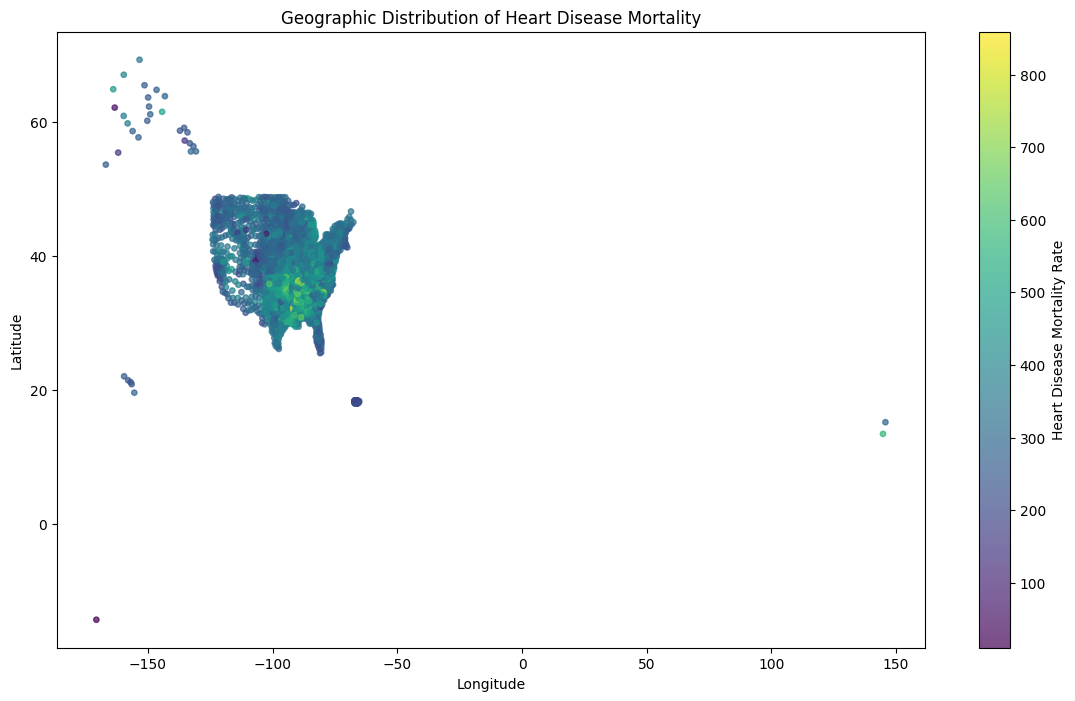

In [ ]:
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    county_overall["X_lon"],
    county_overall["Y_lat"],
    c=county_overall["Data_Value"],
    s=15,
    alpha=0.7
)

plt.colorbar(
    scatter,
    label="Heart Disease Mortality Rate"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Heart Disease Mortality")

plt.show()